# LES FESTIVALES FRANCAIS

In [45]:
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt

In [23]:
data_path = "./data/festivals-global-festivals-pl.csv"
df = pd.read_csv(data_path, sep=';')

In [24]:
outre_mer = [
    "Corse",
    "Corse",
    "Guadeloupe",
    "La Réunion",
    "Guyane",
    "Martinique",
    "Mayotte",
    "Polynésie française",
    "Nouvelle-Calédonie",
    "Saint-Barthélemy",
    "Saint-Pierre-et-Miquelon"
]
df = df[~df["Région principale de déroulement"].isin(outre_mer)]
df[['Y', 'X']] = df["Géocodage xy"].str.split(',', expand=True)
df['X'] = df['X'].astype(float)
df['Y'] = df['Y'].astype(float)
df.head()



,﻿Name,Envergure territoriale,Région principale de déroulement,Département principal de déroulement,Commune principale de déroulement,Code postal (de la commune principale de déroulement),Code Insee commune,Code Insee EPCI,Libellé EPCI,Numéro de voie,...,Sous-catégorie cinéma et audiovisuel,Sous-catégorie arts visuels et arts numériques,Sous-catégorie livre et littérature,Période principale de déroulement du festival,Identifiant Agence A,Identifiant,Géocodage xy,identifiant CNM,Y,X
0,Des Planches et des Vaches,NaN,Normandie,Calvados,Hérouville-Saint-Clair,14200,14327,200065597,CU Caen la Mer,1,...,NaN,NaN,"Bande dessinée, comics, manga",Avant-saison (1er janvier - 20 juin),NaN,FEST_14327_2572,"49.2073560619, -0.331022626025",NaN,49.207356,-0.331023
1,Festival celte en Gevaudan,Régionale,Auvergne-Rhône-Alpes,Haute-Loire,Saugues,43170,43234,200073393,CC des Rives du Haut-Allier,1,...,NaN,NaN,NaN,Saison (21 juin - 5 septembre),NaN,FEST_43234_6254,"44.9482034569, 3.53883236387",NaN,44.948203,3.538832
2,Festival International de Châteauroux - DARC,Interrégionale,Centre-Val de Loire,Indre,Châteauroux,36000,36044,243600327,CA Châteauroux Métropole,10 bis,...,NaN,NaN,NaN,Saison (21 juin - 5 septembre),NaN,FEST_36044_1549,"46.8029617828, 1.69399812001",NaN,46.802962,1.693998
3,Contre-plongées de l'été,NaN,Auvergne-Rhône-Alpes,Puy-de-Dôme,Clermont-Ferrand,63000,63113,246300701,Clermont Auvergne Métropole,NaN,...,NaN,NaN,NaN,Saison (21 juin - 5 septembre),NaN,FEST_63113_1668,"45.7856492991, 3.11554542903",NaN,45.785649,3.115545
4,Festival des Filets Bleus,NaN,Bretagne,Finistère,Concarneau,29900,29039,242900769,CA Concarneau Cornouaille Agglomération,NaN,...,NaN,NaN,NaN,Saison (21 juin - 5 septembre),NaN,FEST_29039_1777,"47.8966260003, -3.90716871821",NaN,47.896626,-3.907169


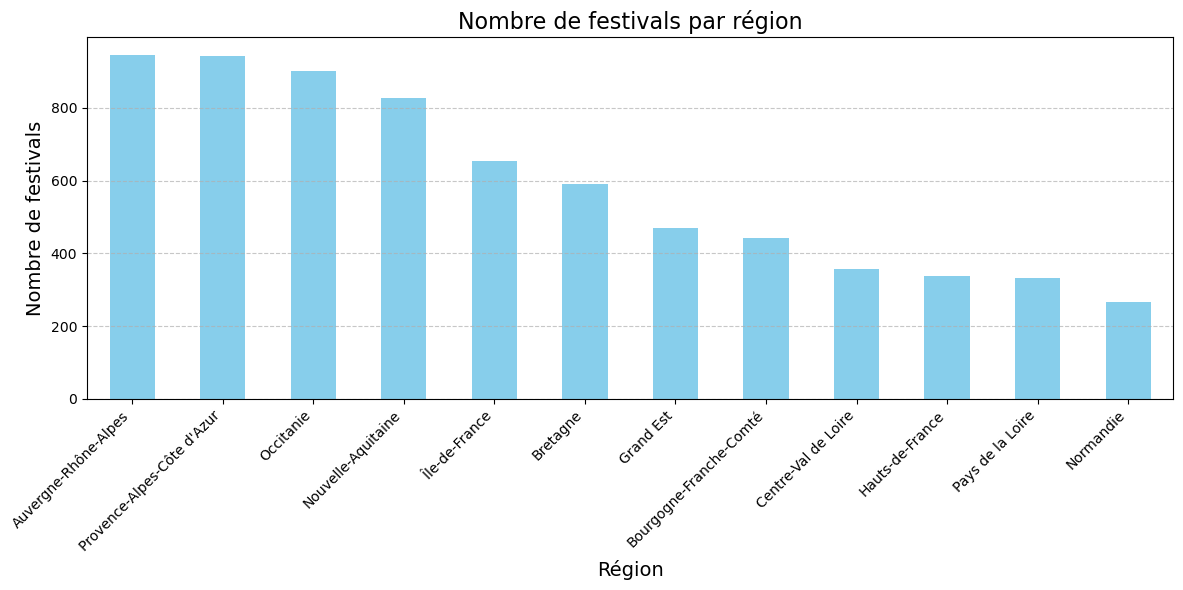

In [25]:
nb_par_region = df["Région principale de déroulement"].value_counts()

plt.figure(figsize=(12, 6))

nb_par_region.plot(kind='bar', color='skyblue')

plt.title('Nombre de festivals par région', fontsize=16)
plt.xlabel('Région', fontsize=14)
plt.ylabel('Nombre de festivals', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() 
plt.show()

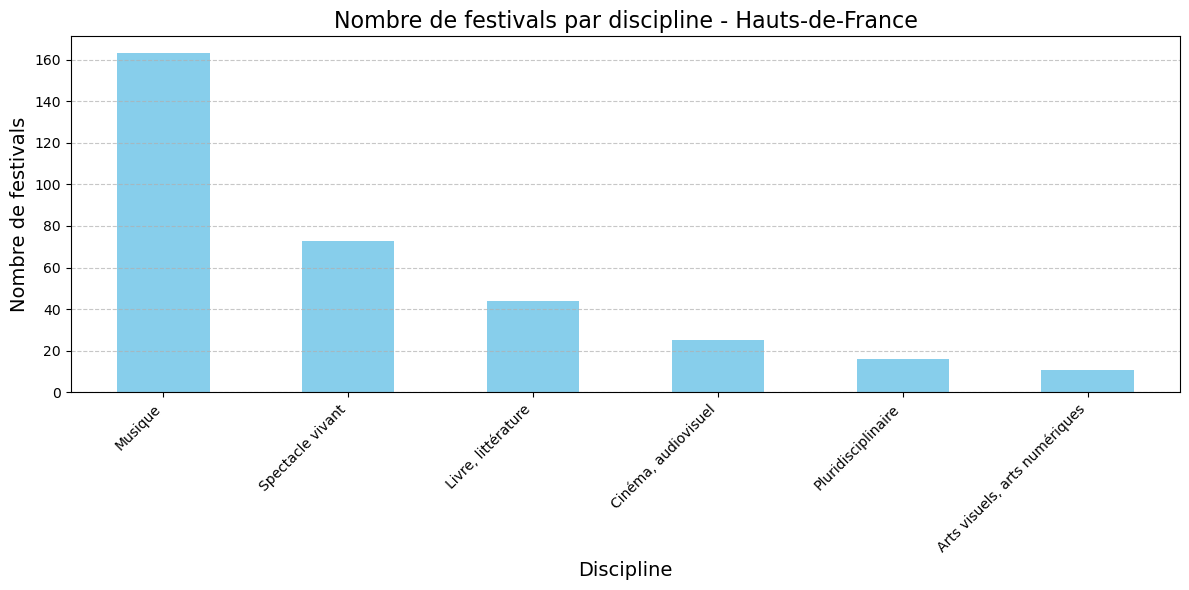

In [26]:
mask = df["Région principale de déroulement"] == "Pays de la Loire"
nb_par_region = df.loc[mask, "Discipline dominante"].value_counts()

plt.figure(figsize=(12, 6))

nb_par_region.plot(kind='bar', color='skyblue')

plt.title('Nombre de festivals par discipline - Hauts-de-France', fontsize=16)
plt.xlabel('Discipline', fontsize=14)
plt.ylabel('Nombre de festivals', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

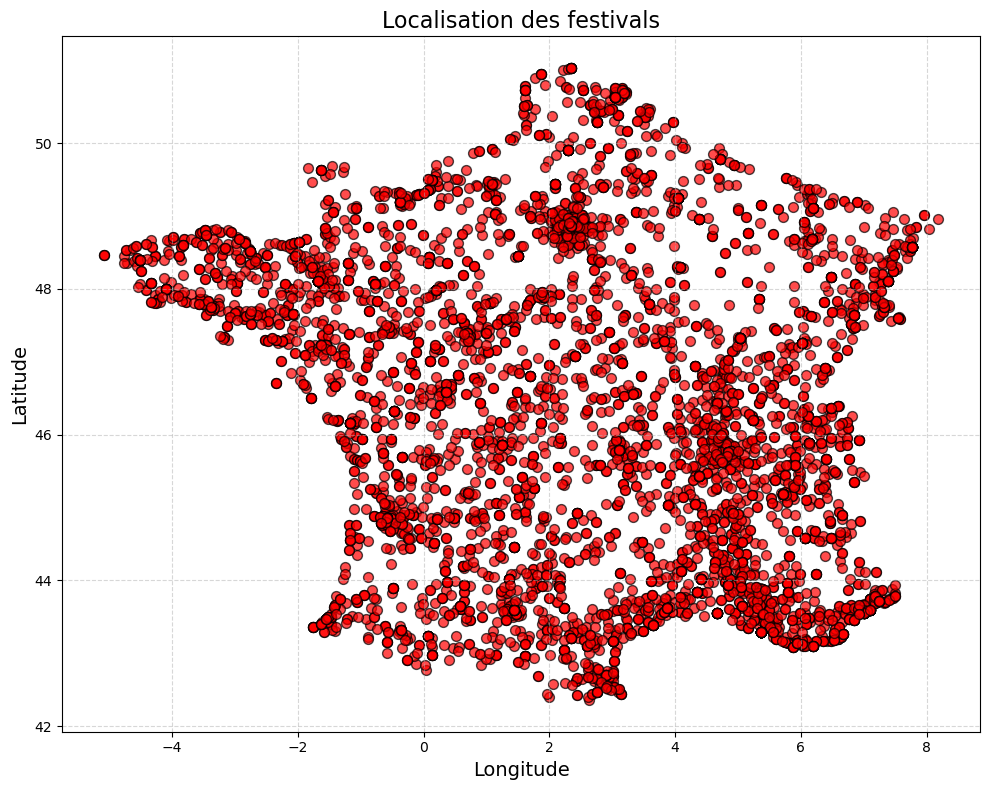

In [27]:
plt.figure(figsize=(10, 8))

plt.scatter(df['X'], df['Y'], c='red', s=50, alpha=0.7, edgecolors='black')

plt.title('Localisation des festivals', fontsize=16)
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [28]:
url = "https://france-geojson.gregoiredavid.fr/repo/regions.geojson"
gdf = gpd.read_file(url)

In [29]:
REGION_NAME_COL = "nom"
gdf = gdf[~gdf[REGION_NAME_COL].isin(outre_mer)]

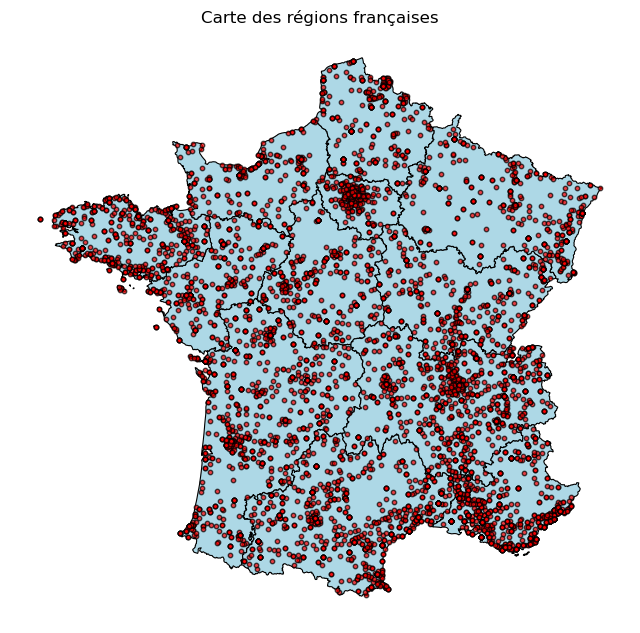

In [30]:

fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.8,
    facecolor="lightblue"
)

ax.set_title("Carte des régions françaises")
ax.axis("off")
plt.scatter(df['X'], df['Y'], c='red', s=10, alpha=0.7, edgecolors='black')
plt.show()


In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt
# We use a PySAL example shapefile

tracts = gpd.GeoDataFrame.from_file(data_path)
print("Observations, Attributes:", tracts.shape)
tracts.head()



Observations, Attributes: (7283, 30)


/opt/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: Selecting ';' as CSV field separator, but other candidate separator(s) have been found.
  return ogr_read(


,﻿Name,Envergure territoriale,Région principale de déroulement,Département principal de déroulement,Commune principale de déroulement,Code postal (de la commune principale de déroulement),Code Insee commune,Code Insee EPCI,Libellé EPCI,Numéro de voie,...,Sous-catégorie musique,Sous-catégorie Musique CNM,Sous-catégorie cinéma et audiovisuel,Sous-catégorie arts visuels et arts numériques,Sous-catégorie livre et littérature,Période principale de déroulement du festival,Identifiant Agence A,Identifiant,Géocodage xy,identifiant CNM
0,Des Planches et des Vaches,,Normandie,Calvados,Hérouville-Saint-Clair,14200,14327,200065597,CU Caen la Mer,1,...,,,,,"Bande dessinée, comics, manga",Avant-saison (1er janvier - 20 juin),,FEST_14327_2572,"49.2073560619, -0.331022626025",
1,Festival celte en Gevaudan,Régionale,Auvergne-Rhône-Alpes,Haute-Loire,Saugues,43170,43234,200073393,CC des Rives du Haut-Allier,1,...,Musique celtique,,,,,Saison (21 juin - 5 septembre),,FEST_43234_6254,"44.9482034569, 3.53883236387",
2,Festival International de Châteauroux - DARC,Interrégionale,Centre-Val de Loire,Indre,Châteauroux,36000,36044,243600327,CA Châteauroux Métropole,10 bis,...,"Chanson ou variété française, Jazz, blues, Hip...",,,,,Saison (21 juin - 5 septembre),,FEST_36044_1549,"46.8029617828, 1.69399812001",
3,Contre-plongées de l'été,,Auvergne-Rhône-Alpes,Puy-de-Dôme,Clermont-Ferrand,63000,63113,246300701,Clermont Auvergne Métropole,,...,,,,,,Saison (21 juin - 5 septembre),,FEST_63113_1668,"45.7856492991, 3.11554542903",
4,Festival des Filets Bleus,,Bretagne,Finistère,Concarneau,29900,29039,242900769,CA Concarneau Cornouaille Agglomération,,...,"Chanson ou variété française, Musiques du mond...",,,,,Saison (21 juin - 5 septembre),,FEST_29039_1777,"47.8966260003, -3.90716871821",


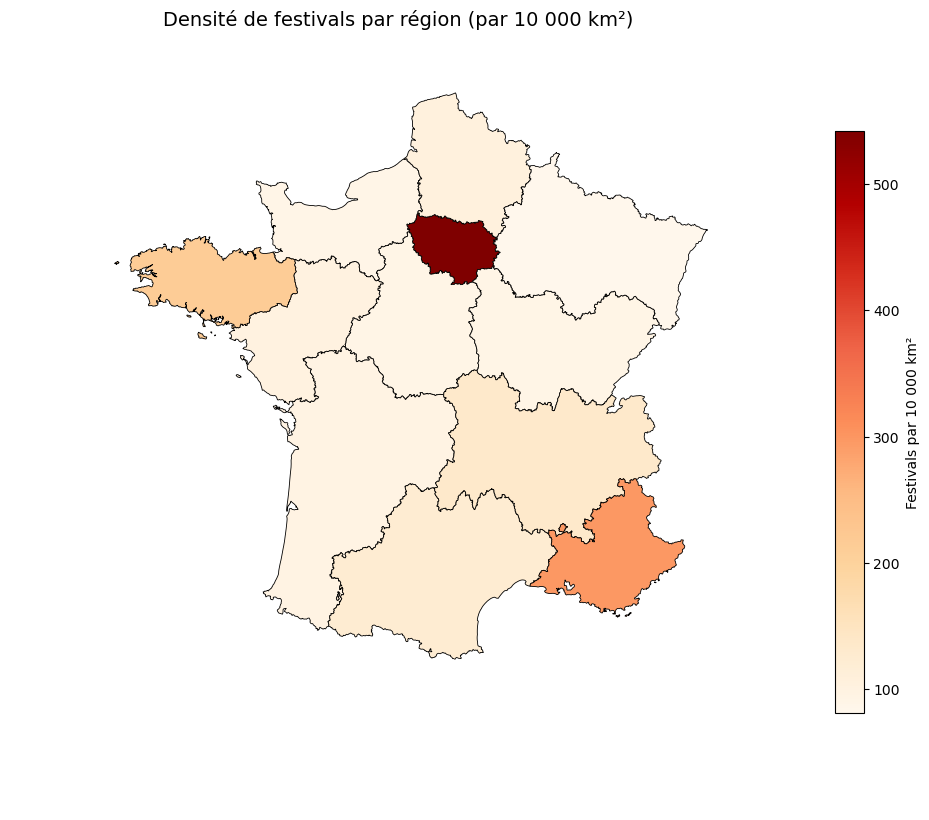

In [32]:

fest_counts = (
    tracts["Région principale de déroulement"]
    .astype(str)
    .str.strip()
    .value_counts()
    .rename_axis("_key")
    .reset_index(name="fest_count")
)


regions_with_density = gdf.copy()
regions_with_density["_key"] = regions_with_density[REGION_NAME_COL].astype(str).str.strip()
regions_with_density = regions_with_density.merge(fest_counts, on="_key", how="left")
regions_with_density["fest_count"] = regions_with_density["fest_count"].fillna(0)


areas_km2 = regions_with_density.to_crs(3035).geometry.area / 1e6
regions_with_density["area_km2"] = areas_km2.replace({0: float("nan")})


regions_with_density["density_per_10k_km2"] = (
    regions_with_density["fest_count"] * 10000 / regions_with_density["area_km2"]
)


fig2, ax2 = plt.subplots(figsize=(10, 10))
regions_with_density.plot(
    column="density_per_10k_km2",
    ax=ax2,
    cmap="OrRd",
    edgecolor="black",
    linewidth=0.6,
    legend=True,
    legend_kwds={"label": "Festivals par 10 000 km²", "shrink": 0.6},
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "Données manquantes"},
)

ax2.set_title("Densité de festivals par région (par 10 000 km²)", fontsize=14)
ax2.axis("off")
plt.xlim(-7.5, 10)
plt.ylim(40,52)
plt.tight_layout()
plt.show()

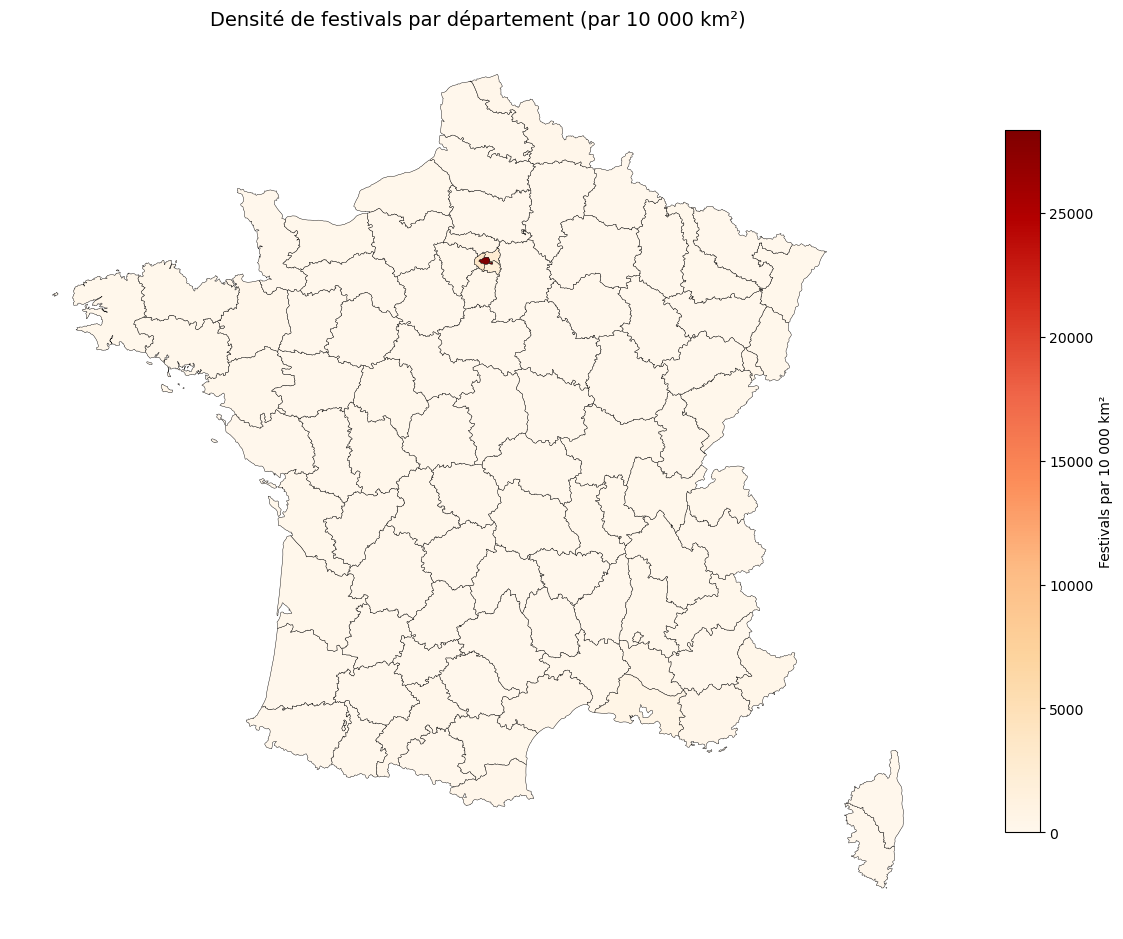

In [33]:
# Get department-level GeoJSON data
dept_url = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"
gdf_dept = gpd.read_file(dept_url)

# Count festivals by department
dept_counts = (
    df["Département principal de déroulement"]
    .astype(str)
    .str.strip()
    .value_counts()
    .rename_axis("_key")
    .reset_index(name="fest_count")
)

# Merge with geodataframe
dept_with_density = gdf_dept.copy()
dept_with_density["_key"] = dept_with_density["nom"].astype(str).str.strip()
dept_with_density = dept_with_density.merge(dept_counts, on="_key", how="left")
dept_with_density["fest_count"] = dept_with_density["fest_count"].fillna(0)

# Calculate area and density
dept_areas_km2 = dept_with_density.to_crs(3035).geometry.area / 1e6
dept_with_density["area_km2"] = dept_areas_km2.replace({0: float("nan")})

dept_with_density["density_per_10k_km2"] = (
    dept_with_density["fest_count"] * 10000 / dept_with_density["area_km2"]
)

# Plot
fig3, ax3 = plt.subplots(figsize=(12, 12))
dept_with_density.plot(
    column="density_per_10k_km2",
    ax=ax3,
    cmap="OrRd",
    edgecolor="black",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Festivals par 10 000 km²", "shrink": 0.6},
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "Données manquantes"},
)

ax3.set_title("Densité de festivals par département (par 10 000 km²)", fontsize=14)
ax3.axis("off")
plt.tight_layout()
plt.show()

In [34]:
villes = {
    'Paris': (48.8566, 2.3522),
    'Marseille': (43.2965, 5.3698),
    'Lyon': (45.7640, 4.8357),
    'Toulouse': (43.6047, 1.4442),
    'Nice': (43.7102, 7.2620),
    'Nantes': (47.2184, -1.5536),
    'Strasbourg': (48.5734, 7.7521),
    'Montpellier': (43.6108, 3.8767),
    'Bordeaux': (44.8378, -0.5792),
    'Lille': (50.6292, 3.0573),
    'Rennes': (48.1173, -1.6778),
    'Reims': (49.2583, 4.0317),
    'Toulon': (43.1242, 5.9280),
    'Saint-Étienne': (45.4397, 4.3872),
    'Le Havre': (49.4944, 0.1079),
    'Grenoble': (45.1885, 5.7245),
    'Dijon': (47.3220, 5.0415),
    'Angers': (47.4784, -0.5632),
    'Nîmes': (43.8367, 4.3601),
    'Clermont-Ferrand': (45.7772, 3.0870)
}

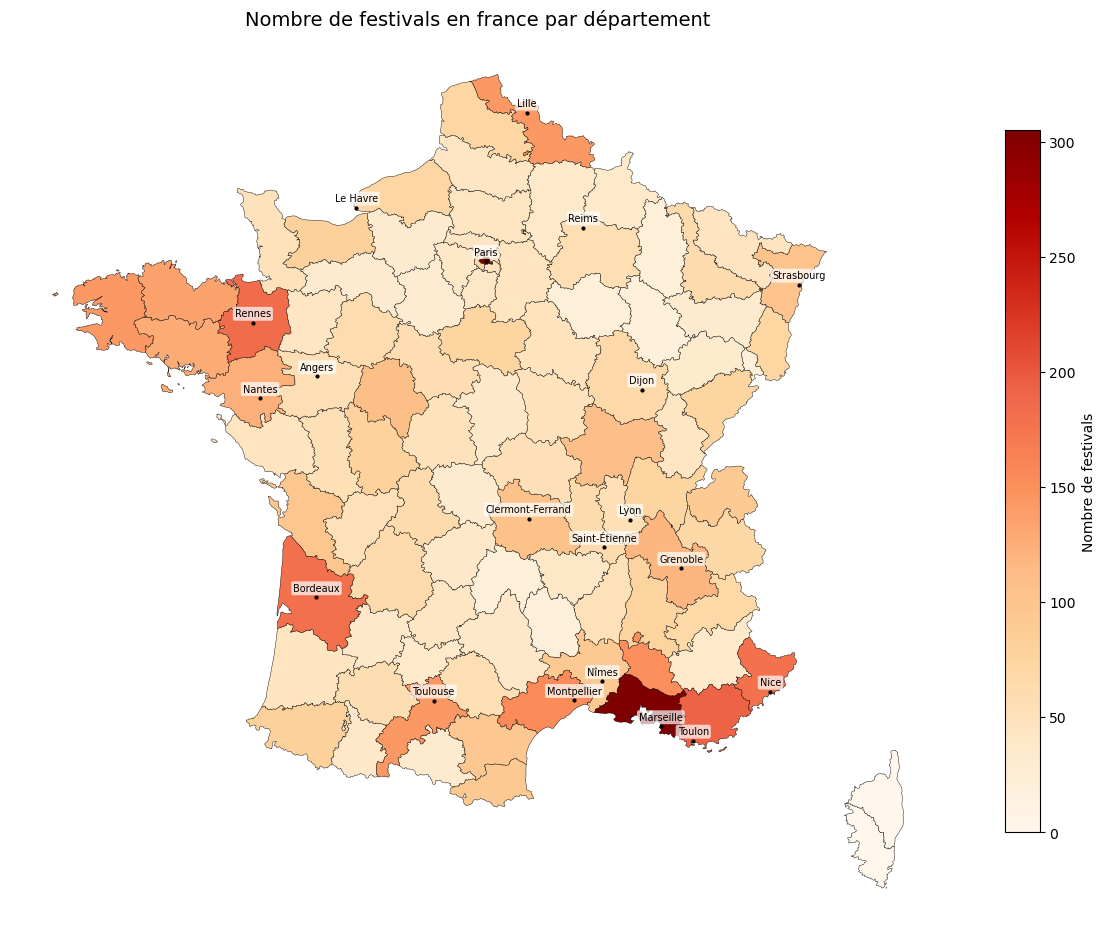

In [44]:
fig4, ax4 = plt.subplots(figsize=(12, 12))
dept_with_density.plot(
    column="fest_count",
    ax=ax4,
    cmap="OrRd",
    edgecolor="black",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Nombre de festivals", "shrink": 0.6},
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "Données manquantes"},
)

for ville, (lat, lon) in villes.items():
    ax4.plot(lon, lat, 'o', color='black', markersize=2)
    ax4.text(lon, lat + 0.05, ville, fontsize=7, ha='center', va='bottom', fontweight='normal',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

ax4.set_title("Nombre de festivals en france par département", fontsize=14)
ax4.axis("off")
plt.tight_layout()
plt.show()